# Final comparison of model families

This notebook uses the fixed `validate` fold as the **evaluation/tune fold** for model selection. Within each family (CNN, extended CNNs, attention), the variant with the highest tune macro-F1 is selected. The `test` fold is deliberately not loaded until those three winners are frozen. It is then used once for the final, clearly labeled comparison. Looking at test results and subsequently changing the model would turn the test fold into another tuning fold.

Besides accuracy and macro-F1, the comparison includes balanced accuracy, macro precision/recall, Matthews correlation coefficient (MCC), one-vs-rest ROC-AUC, average precision (AP), log loss and multiclass Brier score. AP is useful when class frequencies differ; MCC summarizes the full confusion matrix; log loss and Brier score expose overconfident probability errors.

## 1. Setup and required artifacts

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, average_precision_score,
    balanced_accuracy_score, classification_report, f1_score, log_loss,
    matthews_corrcoef, precision_recall_curve, precision_score, recall_score,
    roc_auc_score, roc_curve,
)
from sklearn.preprocessing import label_binarize
from torch.utils.data import DataLoader, TensorDataset

from pytorch_timecourse_classification.artifacts import (
    artifact_root, load_model, save_selection_manifest,
)
from pytorch_timecourse_classification.data import (
    Preprocessor, load_prepared_fold, preprocessors_compatible,
)

In [2]:
ARTIFACT_PREFIXES = {
    "cnn": "cnn_",
    "extended_cnns": "extended_cnn_",
    "attention": "attention_",
}
artifacts_root = artifact_root()
if not artifacts_root.is_dir():
    raise FileNotFoundError(f"Artifacts directory does not exist: {artifacts_root}")
FAMILY_CANDIDATES = {
    family: tuple(sorted(
        path.name for path in artifacts_root.iterdir()
        if (
            path.is_dir() and path.name.startswith(prefix)
            and (path / "model.pt").is_file()
        )
    ))
    for family, prefix in ARTIFACT_PREFIXES.items()
}
empty_families = [family for family, candidates in FAMILY_CANDIDATES.items() if not candidates]
if empty_families:
    raise FileNotFoundError(f"No artifact folders found for: {empty_families}")
artifact_paths = {
    experiment: artifacts_root / experiment / "model.pt"
    for experiments in FAMILY_CANDIDATES.values() for experiment in experiments
}
print("Discovered candidates:", FAMILY_CANDIDATES)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

Discovered candidates: {'cnn': ('cnn_width8_optimizer',), 'extended_cnns': ('extended_cnn_fft', 'extended_cnn_first_difference', 'extended_cnn_gated_fusion', 'extended_cnn_multi_scale', 'extended_cnn_ordinal', 'extended_cnn_shift_robust', 'extended_cnn_tcn'), 'attention': ('attention_cls_attention', 'attention_cnn_attention_pooling', 'attention_hierarchical_patch', 'attention_mean_attention')}
device: cuda


## 2. Probability predictions and metrics

In [3]:
def predict_probabilities(model, features, batch_size=256):
    loader = DataLoader(TensorDataset(features), batch_size=batch_size, shuffle=False)
    batches = []
    model.eval()
    with torch.no_grad():
        for (batch,) in loader:
            batches.append(model(batch.to(device)).softmax(dim=1).cpu())
    return torch.cat(batches).numpy()


def classification_metrics(targets, probabilities, class_labels):
    predictions = probabilities.argmax(axis=1)
    binary_targets = label_binarize(targets, classes=class_labels)
    return {
        "accuracy": accuracy_score(targets, predictions),
        "balanced_accuracy": balanced_accuracy_score(targets, predictions),
        "macro_precision": precision_score(targets, predictions, average="macro", zero_division=0),
        "macro_recall": recall_score(targets, predictions, average="macro", zero_division=0),
        "macro_f1": f1_score(targets, predictions, average="macro", zero_division=0),
        "weighted_f1": f1_score(targets, predictions, average="weighted", zero_division=0),
        "mcc": matthews_corrcoef(targets, predictions),
        "macro_roc_auc_ovr": roc_auc_score(binary_targets, probabilities, average="macro", multi_class="ovr"),
        "macro_average_precision": average_precision_score(binary_targets, probabilities, average="macro"),
        "log_loss": log_loss(targets, probabilities, labels=class_labels),
        "brier_score": np.mean(np.sum((probabilities - binary_targets) ** 2, axis=1)),
    }


def checkpoint_preprocessor(checkpoint):
    return Preprocessor(
        tuple(checkpoint["class_names"]), float(checkpoint["signal_mean"]),
        float(checkpoint["signal_std"]),
    )

## 3. Family-internal selection on eval/tune only

All discovered candidates are evaluated on `validate`. Macro-F1 is the predefined primary selection metric because every dose contributes equally. AP is shown as a probability-ranking diagnostic but does not override the selection rule.

In [4]:
loaded_models = {}
canonical_preprocessor = None
for experiment_name, checkpoint_path in artifact_paths.items():
    model, checkpoint = load_model(checkpoint_path, device=device)
    preprocessor = checkpoint_preprocessor(checkpoint)
    if canonical_preprocessor is None:
        canonical_preprocessor = preprocessor
    elif not preprocessors_compatible(canonical_preprocessor, preprocessor):
        raise ValueError("Candidate checkpoints use different preprocessing or class order.")
    loaded_models[experiment_name] = model

tune_fold = load_prepared_fold("validate", canonical_preprocessor)
class_names = canonical_preprocessor.class_names
class_labels = np.arange(len(class_names))
tune_probabilities = {
    name: predict_probabilities(model, tune_fold.features)
    for name, model in loaded_models.items()
}
candidate_rows = []
for family, experiments in FAMILY_CANDIDATES.items():
    for experiment in experiments:
        metrics = classification_metrics(
            tune_fold.targets.numpy(), tune_probabilities[experiment], class_labels
        )
        candidate_rows.append({"family": family, "experiment": experiment, **metrics})
candidate_comparison = pd.DataFrame(candidate_rows).set_index(["family", "experiment"])
candidate_comparison.round(4)

accuracy  balanced_accuracy  \
family        experiment                                                     
cnn           cnn_width8_optimizer               0.6848             0.7280   
extended_cnns extended_cnn_fft                   0.6991             0.7368   
              extended_cnn_first_difference      0.7077             0.7454   
              extended_cnn_gated_fusion          0.7049             0.7426   
              extended_cnn_multi_scale           0.6332             0.6821   
              extended_cnn_ordinal               0.6275             0.6485   
              extended_cnn_shift_robust          0.6819             0.7135   
              extended_cnn_tcn                   0.7135             0.7086   
attention     attention_cls_attention            0.6504             0.6537   
              attention_cnn_attention_pooling    0.6791             0.6959   
              attention_hierarchical_patch       0.6476             0.6675   
              attention_mean_attention           0.6275             0.6511   

                                               macro_precision  macro_recall  \
family        experiment                                                       
cnn           cnn_width8_optimizer                      0.7132        0.7280   
extended_cnns extended_cnn_fft                          0.7136        0.7368   
              extended_cnn_first_difference             0.7229        0.7454   
              extended_cnn_gated_fusion                 0.7221        0.7426   
              extended_cnn_multi_scale                  0.6566        0.6821   
              extended_cnn_ordinal                      0.6417        0.6485   
              extended_cnn_shift_robust                 0.6870        0.7135   
              extended_cnn_tcn                          0.7075        0.7086   
attention     attention_cls_attention                   0.6575        0.6537   
              attention_cnn_attention_pooling           0.6986        0.6959   
              attention_hierarchical_patch              0.6596        0.6675   
              attention_mean_attention                  0.6284        0.6511   

                                               macro_f1  weighted_f1     mcc  \
family        experiment                                                       
cnn           cnn_width8_optimizer               0.6972       0.6861  0.6299   
extended_cnns extended_cnn_fft                   0.7035       0.6992  0.6472   
              extended_cnn_first_difference      0.7133       0.7073  0.6567   
              extended_cnn_gated_fusion          0.7161       0.7058  0.6512   
              extended_cnn_multi_scale           0.6444       0.6291  0.5692   
              extended_cnn_ordinal               0.6333       0.6260  0.5553   
              extended_cnn_shift_robust          0.6907       0.6824  0.6193   
              extended_cnn_tcn                   0.7059       0.7160  0.6524   
attention     attention_cls_attention            0.6504       0.6512  0.5767   
              attention_cnn_attention_pooling    0.6838       0.6815  0.6169   
              attention_hierarchical_patch       0.6579       0.6513  0.5750   
              attention_mean_attention           0.6331       0.6246  0.5516   

                                               macro_roc_auc_ovr  \
family        experiment                                           
cnn           cnn_width8_optimizer                        0.9352   
extended_cnns extended_cnn_fft                            0.9382   
              extended_cnn_first_difference               0.9381   
              extended_cnn_gated_fusion                   0.9373   
              extended_cnn_multi_scale                    0.9184   
              extended_cnn_ordinal                        0.9071   
              extended_cnn_shift_robust                   0.9371   
              extended_cnn_tcn                            0.9375   
attention     attention_cls_atte

In [5]:
family_winners = {
    family: candidate_comparison.loc[family, "macro_f1"].idxmax()
    for family in FAMILY_CANDIDATES
}
print("Frozen family winners selected without test data:")
for family, winner in family_winners.items():
    print(f"  {family}: {winner}")

extended_top_three = (
    candidate_comparison.loc["extended_cnns"]
    .sort_values("macro_f1", ascending=False)
    .head(3)
)
if len(extended_top_three) != 3:
    raise RuntimeError("At least three Extended-CNN artifacts are required for Notebook 04.")
selection_path = save_selection_manifest(
    "extended_cnns_top3.json",
    candidates=[
        {"rank": rank, "experiment": experiment, **row.to_dict()}
        for rank, (experiment, row) in enumerate(
            extended_top_three.iterrows(), start=1
        )
    ],
    selection_fold="validate",
    selection_metric="macro_f1",
    source_notebook="03_model_family_comparison.ipynb",
)
print("Frozen top-three Extended CNNs for Notebook 04:")
display(extended_top_three.round(4))
print(selection_path)

Frozen family winners selected without test data:
  cnn: cnn_width8_optimizer
  extended_cnns: extended_cnn_gated_fusion
  attention: attention_cnn_attention_pooling
Frozen top-three Extended CNNs for Notebook 04:


,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,mcc,macro_roc_auc_ovr,macro_average_precision,log_loss,brier_score
experiment,,,,,,,,,,,
extended_cnn_gated_fusion,0.7049,0.7426,0.7221,0.7426,0.7161,0.7058,0.6512,0.9373,0.7440,0.7326,0.4091
extended_cnn_first_difference,0.7077,0.7454,0.7229,0.7454,0.7133,0.7073,0.6567,0.9381,0.7501,0.7431,0.4037
extended_cnn_tcn,0.7135,0.7086,0.7075,0.7086,0.7059,0.7160,0.6524,0.9375,0.7512,0.7072,0.3731


/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/selections/extended_cnns_top3.json


## 4. Final tune and test comparison

The three family winners and the three Extended-CNN candidates for Notebook 04 are now frozen using only `validate`. Only from this point onward is `test` loaded. Tune metrics describe model selection; test metrics estimate final generalization. The XAI notebook consumes the saved tune-only selection manifest and does not rank models by test behavior.

In [6]:
test_fold = load_prepared_fold("test", canonical_preprocessor)
folds = {"tune (validate)": tune_fold, "test": test_fold}
winner_probabilities = {fold_name: {} for fold_name in folds}
final_rows = []
for fold_name, fold in folds.items():
    for family, experiment in family_winners.items():
        probabilities = (
            tune_probabilities[experiment] if fold_name == "tune (validate)"
            else predict_probabilities(loaded_models[experiment], fold.features)
        )
        winner_probabilities[fold_name][family] = probabilities
        metrics = classification_metrics(fold.targets.numpy(), probabilities, class_labels)
        final_rows.append({"fold": fold_name, "family": family, "experiment": experiment, **metrics})
final_comparison = pd.DataFrame(final_rows).set_index(["fold", "family"])
final_comparison.round(4)

experiment  accuracy  \
fold            family                                                     
tune (validate) cnn                       cnn_width8_optimizer    0.6848   
                extended_cnns        extended_cnn_gated_fusion    0.7049   
                attention      attention_cnn_attention_pooling    0.6791   
test            cnn                       cnn_width8_optimizer    0.6963   
                extended_cnns        extended_cnn_gated_fusion    0.6905   
                attention      attention_cnn_attention_pooling    0.6877   

                               balanced_accuracy  macro_precision  \
fold            family                                              
tune (validate) cnn                       0.7280           0.7132   
                extended_cnns             0.7426           0.7221   
                attention                 0.6959           0.6986   
test            cnn                       0.7336           0.7232   
                extended_cnns             0.7330           0.7119   
                attention                 0.7046           0.6908   

                               macro_recall  macro_f1  weighted_f1     mcc  \
fold            family                                                       
tune (validate) cnn                  0.7280    0.6972       0.6861  0.6299   
                extended_cnns        0.7426    0.7161       0.7058  0.6512   
                attention            0.6959    0.6838       0.6815  0.6169   
test            cnn                  0.7336    0.7035       0.6986  0.6445   
                extended_cnns        0.7330    0.6940       0.6875  0.6396   
                attention            0.7046    0.6853       0.6885  0.6269   

                               macro_roc_auc_ovr  macro_average_precision  \
fold            family                                                      
tune (validate) cnn                       0.9352                   0.7337   
                extended_cnns             0.9373                   0.7440   
                attention                 0.9320                   0.7380   
test            cnn                       0.9435                   0.7610   
                extended_cnns             0.9351                   0.7317   
                attention                 0.9356                   0.7358   

                               log_loss  brier_score  
fold            family                                
tune (validate) cnn              0.7336       0.4188  
                extended_cnns    0.7326       0.4091  
                attention        0.7524       0.4218  
test            cnn              0.6953       0.3903  
                extended_cnns    0.7499       0.4246  
                attention        0.6963       0.3988

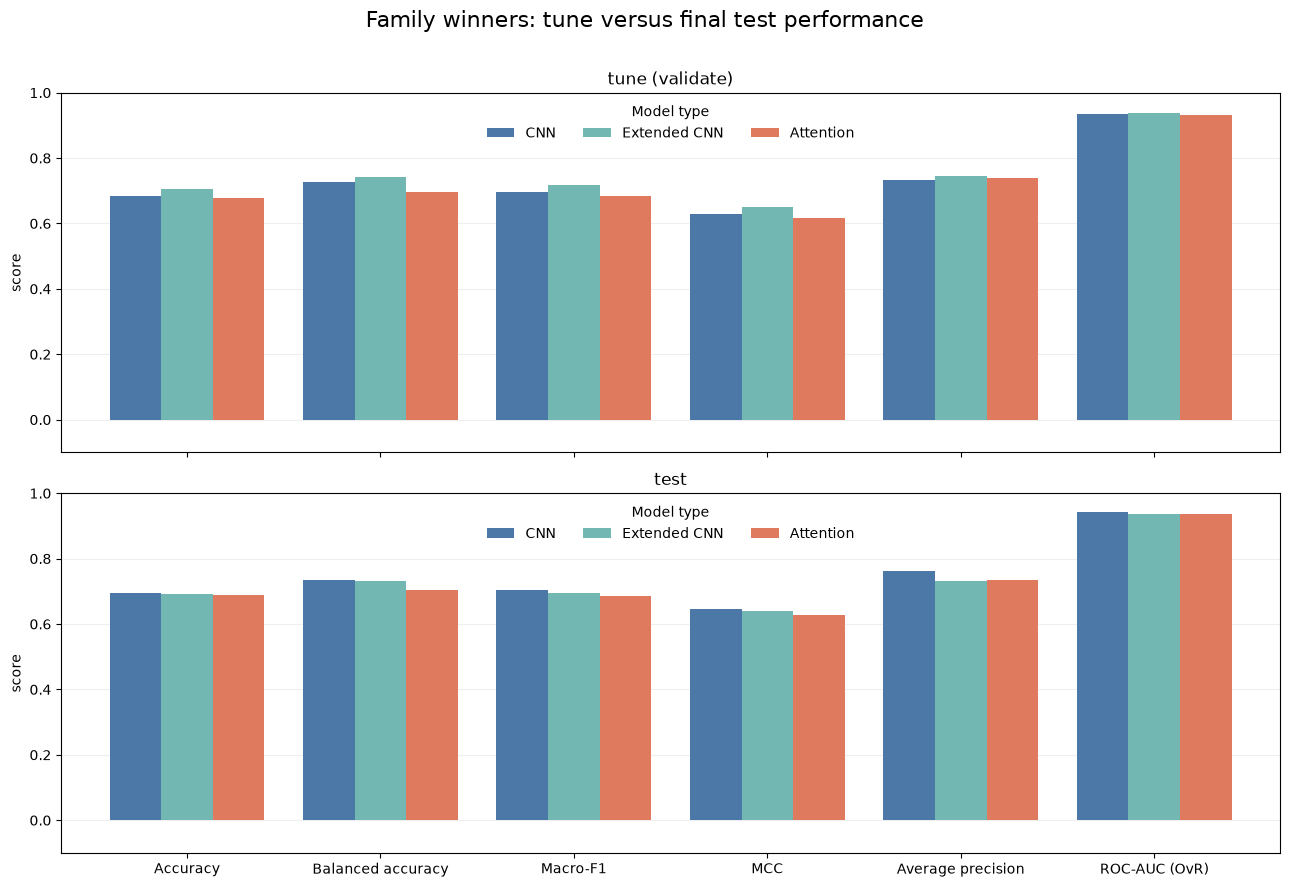

In [7]:
display_metrics = {
    "accuracy": "Accuracy",
    "balanced_accuracy": "Balanced accuracy",
    "macro_f1": "Macro-F1",
    "mcc": "MCC",
    "macro_average_precision": "Average precision",
    "macro_roc_auc_ovr": "ROC-AUC (OvR)",
}
family_labels = {"cnn": "CNN", "extended_cnns": "Extended CNN", "attention": "Attention"}
family_colors = {"cnn": "#4C78A8", "extended_cnns": "#72B7B2", "attention": "#E07A5F"}
figure, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True, sharey=True)
for axis, fold_name in zip(axes, folds):
    plot_data = final_comparison.loc[fold_name, list(display_metrics)].T
    plot_data = plot_data.rename(index=display_metrics, columns=family_labels)
    colors = [family_colors[family] for family in final_comparison.loc[fold_name].index]
    plot_data.plot.bar(ax=axis, color=colors, width=0.8, rot=0, ylim=(-0.1, 1.0))
    axis.set(title=fold_name, xlabel="", ylabel="score")
    axis.grid(axis="y", alpha=0.2)
    axis.set_axisbelow(True)
    axis.legend(title="Model type", loc="upper center", ncol=3, frameon=False)
figure.suptitle("Family winners: tune versus final test performance", fontsize=16)
figure.tight_layout(rect=(0, 0, 1, 0.97))

## 5. Final test reports and confusion matrices


TEST — cnn (cnn_width8_optimizer)
              precision    recall  f1-score   support

         0pM       0.47      1.00      0.64        36
         1pM       0.87      0.50      0.63        78
       2.5pM       0.70      0.64      0.67        66
         5pM       0.58      0.65      0.61        62
        25pM       0.89      0.79      0.84        72
       100pM       0.83      0.83      0.83        35

    accuracy                           0.70       349
   macro avg       0.72      0.73      0.70       349
weighted avg       0.74      0.70      0.70       349


TEST — extended_cnns (extended_cnn_gated_fusion)
              precision    recall  f1-score   support

         0pM       0.47      1.00      0.64        36
         1pM       0.85      0.45      0.59        78
       2.5pM       0.67      0.56      0.61        66
         5pM       0.64      0.73      0.68        62
        25pM       0.87      0.81      0.83        72
       100pM       0.77      0.86      0.81    

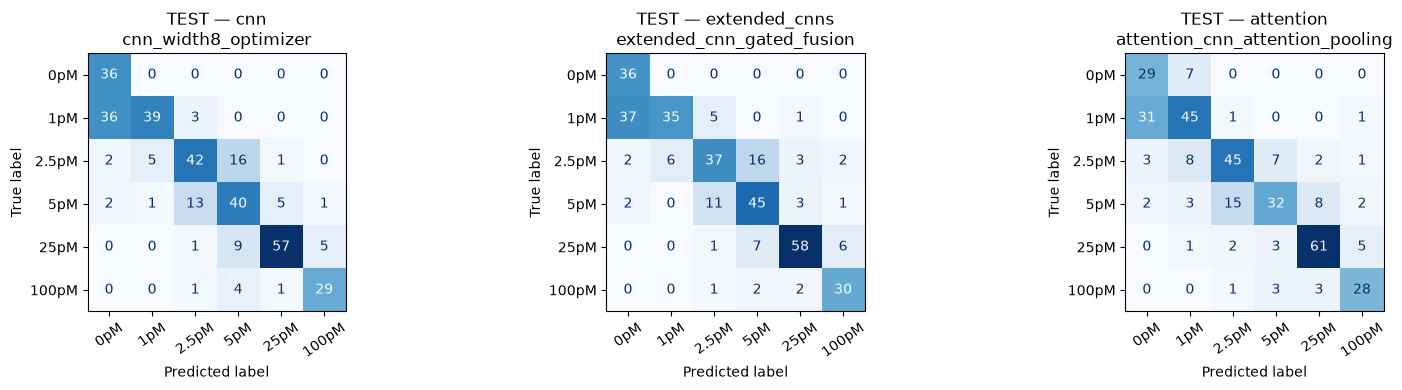

In [8]:
figure, axes = plt.subplots(1, 3, figsize=(16, 4))
for axis, (family, experiment) in zip(axes, family_winners.items()):
    predictions = winner_probabilities["test"][family].argmax(axis=1)
    print(f"\nTEST — {family} ({experiment})")
    print(classification_report(
        test_fold.targets.numpy(), predictions, labels=class_labels,
        target_names=class_names, zero_division=0,
    ))
    ConfusionMatrixDisplay.from_predictions(
        test_fold.targets.numpy(), predictions, labels=class_labels,
        display_labels=class_names, xticks_rotation=35, cmap="Blues",
        ax=axis, colorbar=False,
    )
    axis.set_title(f"TEST — {family}\n{experiment}")
figure.tight_layout()

## 6. Test ROC and precision–recall curves

Curves are one-vs-rest for each dose. ROC can look optimistic when negatives dominate; precision–recall curves and AP focus more directly on high-confidence positive predictions.

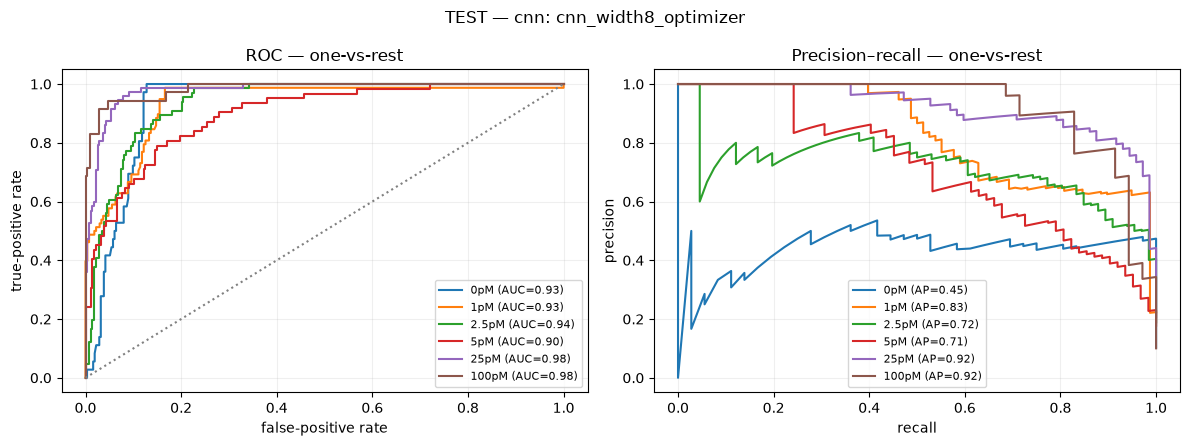

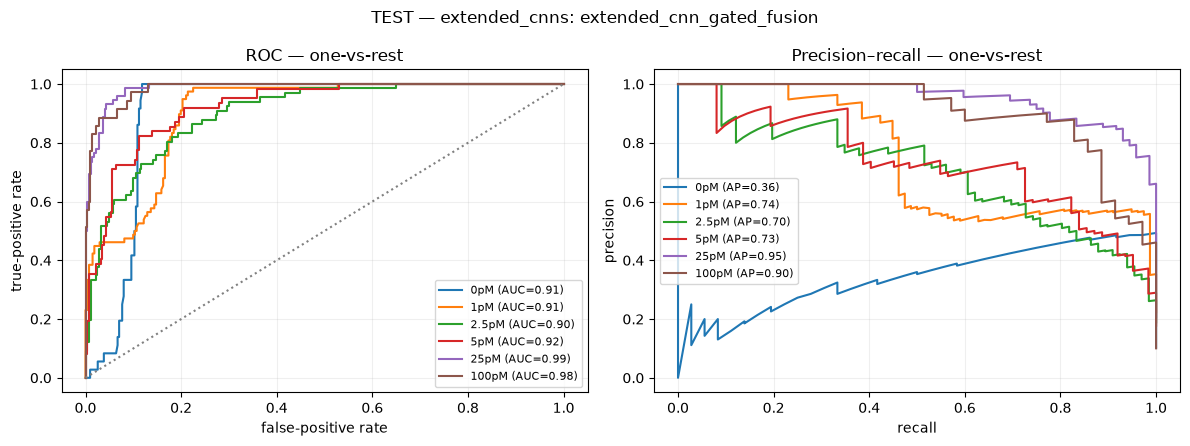

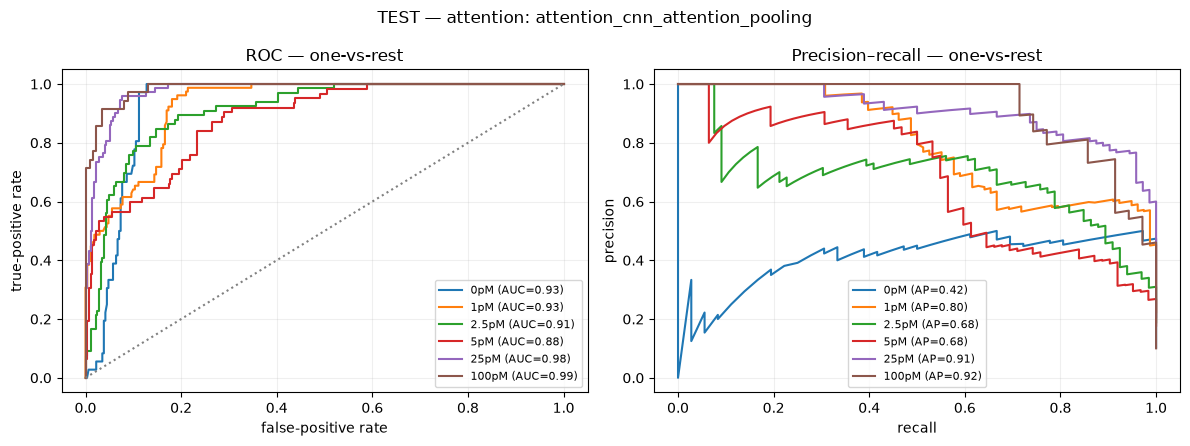

In [9]:
binary_test_targets = label_binarize(test_fold.targets.numpy(), classes=class_labels)
for family, experiment in family_winners.items():
    probabilities = winner_probabilities["test"][family]
    figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    for class_index, class_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(binary_test_targets[:, class_index], probabilities[:, class_index])
        auc = roc_auc_score(binary_test_targets[:, class_index], probabilities[:, class_index])
        precision, recall, _ = precision_recall_curve(binary_test_targets[:, class_index], probabilities[:, class_index])
        ap = average_precision_score(binary_test_targets[:, class_index], probabilities[:, class_index])
        axes[0].plot(fpr, tpr, label=f"{class_name} (AUC={auc:.2f})")
        axes[1].plot(recall, precision, label=f"{class_name} (AP={ap:.2f})")
    axes[0].plot([0, 1], [0, 1], color="0.5", linestyle=":")
    axes[0].set(title="ROC — one-vs-rest", xlabel="false-positive rate", ylabel="true-positive rate")
    axes[1].set(title="Precision–recall — one-vs-rest", xlabel="recall", ylabel="precision")
    for axis in axes:
        axis.legend(fontsize=8)
        axis.grid(alpha=0.2)
    figure.suptitle(f"TEST — {family}: {experiment}")
    figure.tight_layout()

## 7. Interpretation and next steps

In [10]:
gap_metrics = ["accuracy", "balanced_accuracy", "macro_f1", "mcc", "macro_average_precision", "macro_roc_auc_ovr"]
generalization_gaps = (
    final_comparison.loc["test", gap_metrics]
    - final_comparison.loc["tune (validate)", gap_metrics]
)
generalization_gaps.round(4)

,accuracy,balanced_accuracy,macro_f1,mcc,macro_average_precision,macro_roc_auc_ovr
family,,,,,,
cnn,0.0115,0.0057,0.0063,0.0146,0.0273,0.0083
extended_cnns,-0.0143,-0.0097,-0.0221,-0.0116,-0.0123,-0.0022
attention,0.0086,0.0087,0.0016,0.0100,-0.0022,0.0036


A small tune–test difference across macro-F1, MCC and AP supports stable generalization. A large test drop suggests selection variance, residual experiment-level leakage, or sensitivity to the fixed split; it should not trigger another round of tuning on test. If accuracy remains high while macro-F1 or AP is weak, inspect class curves and confusion matrices for neglected doses. High ROC-AUC with weaker AP is possible under one-vs-rest imbalance and is not uniformly strong classification.

Next, attach uncertainty with stratified bootstrap confidence intervals and repeat training across seeds while keeping test untouched. Examine probability calibration with reliability diagrams or expected calibration error before using confidence thresholds. If trajectories share biological replicates, repeat the complete protocol with group-aware folds.